In [1]:
import numpy as np
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to our saved file
data_path = '/content/drive/MyDrive/AI_Physio_Coach/vicon_processed_data.npz'

# Load the data
# We use 'with np.load(...) as data:' which is a safe way to open .npz files
with np.load(data_path) as data:
    X_data = data['sequences']
    y_data = data['labels']

print("--- Data Successfully Loaded ---")
print(f"Shape of sequences (X_data): {X_data.shape}")
print(f"Shape of labels (y_data): {y_data.shape}")
print(f"Total 'Correct' (0) samples: {np.sum(y_data == 0)}")
print(f"Total 'Error' (1) samples: {np.sum(y_data == 1)}")

Mounted at /content/drive
--- Data Successfully Loaded ---
Shape of sequences (X_data): (540, 500, 17, 7)
Shape of labels (y_data): (540,)
Total 'Correct' (0) samples: 135
Total 'Error' (1) samples: 405


In [2]:
from sklearn.model_selection import train_test_split

# Define the split ratios
TEST_SIZE = 0.15      # 15% for the final, unseen test set
VAL_SIZE = 0.15       # 15% for the validation set during training
RANDOM_STATE = 42     # For reproducibility

# --- First split: Separate out the Test Set ---
# We stratify by y_data to ensure class balance in both train_val and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_data, y_data,
    test_size=TEST_SIZE,
    stratify=y_data,
    random_state=RANDOM_STATE
)

# --- Second split: Separate Training and Validation from the remaining data ---
# We calculate the new validation size relative to the remaining train_val set
# Example: If TEST_SIZE is 0.15, 85% remains. If VAL_SIZE is 0.15 of original,
# then new_val_size = 0.15 / 0.85 approx 0.1765
new_val_size = VAL_SIZE / (1 - TEST_SIZE)

# Stratify by y_train_val to maintain class balance
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=new_val_size,
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print("\n--- Data Split Summary ---")
print(f"Total samples: {len(X_data)}")
print(f"Training samples: {len(X_train)} (approx {len(X_train)/len(X_data):.1%})")
print(f"Validation samples: {len(X_val)} (approx {len(X_val)/len(X_data):.1%})")
print(f"Test samples: {len(X_test)} (approx {len(X_test)/len(X_data):.1%})")

print("\n--- Class Distribution Check ---")
print("Training Set (Correct/Error):", np.sum(y_train == 0), "/", np.sum(y_train == 1))
print("Validation Set (Correct/Error):", np.sum(y_val == 0), "/", np.sum(y_val == 1))
print("Test Set (Correct/Error):", np.sum(y_test == 0), "/", np.sum(y_test == 1))


--- Data Split Summary ---
Total samples: 540
Training samples: 378 (approx 70.0%)
Validation samples: 81 (approx 15.0%)
Test samples: 81 (approx 15.0%)

--- Class Distribution Check ---
Training Set (Correct/Error): 95 / 283
Validation Set (Correct/Error): 20 / 61
Test Set (Correct/Error): 20 / 61


In [3]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights for the training data
# 'balanced' mode automatically computes weights inversely proportional to class frequencies
# This means: weight for Class 0 = (total_samples / (num_classes * count_class_0))
#             weight for Class 1 = (total_samples / (num_classes * count_class_1))
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), # Should be [0, 1]
    y=y_train
)

# Convert to a dictionary for Keras/TensorFlow
class_weight_dict = dict(enumerate(class_weights))

print("\n--- Calculated Class Weights ---")
print(f"Number of 'Correct' (0) samples in training set: {np.sum(y_train == 0)}")
print(f"Number of 'Error' (1) samples in training set: {np.sum(y_train == 1)}")
print(f"Calculated class weights: {class_weight_dict}")


--- Calculated Class Weights ---
Number of 'Correct' (0) samples in training set: 95
Number of 'Error' (1) samples in training set: 283
Calculated class weights: {0: np.float64(1.9894736842105263), 1: np.float64(0.6678445229681979)}


In [4]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

# # --- 1. DEFINE POSITIONAL EMBEDDING LAYER (Our working version) ---

# class PositionalEmbedding(layers.Layer):
#     def __init__(self, sequence_length, output_dim, **kwargs):
#         super().__init__(**kwargs)
#         self.sequence_length = sequence_length
#         self.output_dim = output_dim
#         self.token_embeddings = layers.Dense(output_dim, activation="relu")
#         self.position_embeddings = layers.Embedding(sequence_length, output_dim)

#     def call(self, inputs, training=None):
#         length = tf.shape(inputs)[1]
#         positions = tf.range(start=0, limit=length, delta=1)
#         embedded_positions = self.position_embeddings(positions)
#         embedded_tokens = self.token_embeddings(inputs, training=training)
#         # This fix was correct
#         return embedded_tokens + embedded_positions[tf.newaxis, :, :]

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             "sequence_length": self.sequence_length,
#             "output_dim": self.output_dim,
#         })
#         return config

# # --- 2. DEFINE THE TRANSFORMER ENCODER LAYER (Guaranteed-to-work version) ---
# # This is the official implementation from Keras, which avoids the bug.

# class TransformerEncoder(layers.Layer):
#     def __init__(self, embed_dim, num_heads, feedforward_dim, rate=0.1, **kwargs):
#         super().__init__(**kwargs)
#         self.embed_dim = embed_dim
#         self.num_heads = num_heads
#         self.feedforward_dim = feedforward_dim
#         self.rate = rate

#         if embed_dim % num_heads != 0:
#             raise ValueError(
#                 f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
#             )

#         self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
#         self.ffn = keras.Sequential(
#             [
#                 layers.Dense(feedforward_dim, activation="relu"),
#                 layers.Dense(embed_dim),
#             ]
#         )
#         self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
#         self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
#         self.dropout1 = layers.Dropout(rate)
#         self.dropout2 = layers.Dropout(rate)

#     def call(self, inputs, training=None):
#         attn_output = self.att(inputs, inputs, inputs, training=training)
#         attn_output = self.dropout1(attn_output, training=training)
#         out1 = self.layernorm1(inputs + attn_output)

#         ffn_output = self.ffn(out1, training=training)
#         ffn_output = self.dropout2(ffn_output, training=training)
#         return self.layernorm2(out1 + ffn_output)

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             "embed_dim": self.embed_dim,
#             "num_heads": self.num_heads,
#             "feedforward_dim": self.feedforward_dim,
#             "rate": self.rate,
#         })
#         return config

# # --- 3. DEFINE MODEL HYPERPARAMETERS ---
# SEQUENCE_LENGTH = X_train.shape[1]  # 500
# NUM_JOINTS = X_train.shape[2]       # 17
# NUM_FEATURES = X_train.shape[3]     # 7
# INPUT_SHAPE = (SEQUENCE_LENGTH, NUM_JOINTS * NUM_FEATURES) # (500, 119)

# EMBED_DIM = 128     # Embedding dimension
# NUM_HEADS = 8       # Number of attention heads
# FF_DIM = 128        # Feed-forward network dimension
# DROPOUT_RATE = 0.1
# NUM_CLASSES = 2
# NUM_ENCODER_BLOCKS = 4

# # --- 4. BUILD THE V1 MODEL (Using our new defined layers) ---

# def build_v1_transformer_model():
#     inputs = layers.Input(shape=(SEQUENCE_LENGTH, NUM_JOINTS, NUM_FEATURES))
#     x = layers.Reshape((SEQUENCE_LENGTH, NUM_JOINTS * NUM_FEATURES))(inputs)
#     x = PositionalEmbedding(SEQUENCE_LENGTH, EMBED_DIM)(x)

#     # We are now stacking our own, correctly-defined TransformerEncoder
#     for _ in range(NUM_ENCODER_BLOCKS):
#         x = TransformerEncoder(EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT_RATE)(x)

#     x = layers.GlobalAveragePooling1D()(x)
#     x = layers.Dropout(0.5)(x)
#     x = layers.Dense(64, activation="relu")(x)
#     x = layers.Dropout(0.5)(x)
#     outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

#     model = keras.Model(inputs=inputs, outputs=outputs)
#     return model

# # --- 5. INSTANTIATE AND COMPILE ---
# v1_model = build_v1_transformer_model()

# v1_model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-4),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"] # Use simple, robust metrics
# )

# v1_model.summary()

# # --- 6. DEFINE CALLBACKS ---
# model_checkpoint_cb = keras.callbacks.ModelCheckpoint(
#     filepath="v1_model_best.keras",
#     save_best_only=True,
#     monitor="val_loss",
#     mode="min"
# )

# early_stopping_cb = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=5,
#     restore_best_weights=True
# )

# # --- 7. SET TRAINING PARAMETERS ---
# EPOCHS = 30
# BATCH_SIZE = 16

# # --- 8. TRAIN THE MODEL! ---
# print("\n--- Starting Model Training ---")

# history = v1_model.fit(
#     X_train, y_train,
#     batch_size=BATCH_SIZE,
#     epochs=EPOCHS,
#     validation_data=(X_val, y_val),
#     class_weight=class_weight_dict, # Apply our class weights
#     callbacks=[model_checkpoint_cb, early_stopping_cb]
# )

# print("\n--- Model Training Complete ---")

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np # Make sure numpy is imported if you're in a new session

# --- 1. DEFINE POSITIONAL EMBEDDING LAYER (Our working version) ---

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.output_dim = output_dim
        self.token_embeddings = layers.Dense(output_dim, activation="relu")
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs, training=None):
        length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_positions = self.position_embeddings(positions)
        embedded_tokens = self.token_embeddings(inputs, training=training)
        return embedded_tokens + embedded_positions[tf.newaxis, :, :]

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "output_dim": self.output_dim,
        })
        return config

# --- 2. DEFINE THE TRANSFORMER ENCODER LAYER (Our working version) ---

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, feedforward_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.feedforward_dim = feedforward_dim
        self.rate = rate
        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
            )
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = keras.Sequential(
            [
                layers.Dense(feedforward_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "feedforward_dim": self.feedforward_dim,
            "rate": self.rate,
        })
        return config

# --- 3. DEFINE **NEW** MODEL HYPERPARAMETERS ---
SEQUENCE_LENGTH = X_train.shape[1]  # 500
NUM_JOINTS = X_train.shape[2]       # 17
NUM_FEATURES = X_train.shape[3]     # 7
NUM_CLASSES = 2

# --- 🚀 HYPERPARAMETER UPGRADES ---
EMBED_DIM = 256     # UPGRADED from 128
FF_DIM = 256        # UPGRADED from 128
NUM_ENCODER_BLOCKS = 6 # UPGRADED from 4
# --- (Num_heads remains 8, as 256 is divisible by 8) ---
NUM_HEADS = 8
DROPOUT_RATE = 0.1

# --- 4. BUILD THE V1 MODEL (Using our new defined layers) ---

def build_v1_transformer_model():
    inputs = layers.Input(shape=(SEQUENCE_LENGTH, NUM_JOINTS, NUM_FEATURES))
    x = layers.Reshape((SEQUENCE_LENGTH, NUM_JOINTS * NUM_FEATURES))(inputs)

    # 1. Token & Positional Embedding
    x = PositionalEmbedding(SEQUENCE_LENGTH, EMBED_DIM)(x)

    # 2. Transformer Encoder Blocks
    for _ in range(NUM_ENCODER_BLOCKS):
        x = TransformerEncoder(EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT_RATE)(x)

    # 3. Classification Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x) # Increased dense layer size
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# --- 5. INSTANTIATE AND COMPILE ---
v1_model = build_v1_transformer_model()

v1_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # 0.0001
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

v1_model.summary()

# --- 6. DEFINE CALLBACKS ---
model_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="v1_model_best.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10, # Increased patience to 10 epochs
    restore_best_weights=True
)

# --- 7. SET TRAINING PARAMETERS ---
EPOCHS = 50 # Increased max epochs to 50
BATCH_SIZE = 16

# --- 8. TRAIN THE MODEL! ---
print("\n--- Starting Model Training (v1 - Upgraded Architecture) ---")

history = v1_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[model_checkpoint_cb, early_stopping_cb]
)

print("\n--- Model Training Complete ---")

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 17, 7)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 500, 119)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 500, 256)       │       158,720 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 500, 256)       │       395,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 500, 256)       │       395,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 500, 256)       │       395,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, 500, 256)       │       395,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_4           │ (None, 500, 256)       │       395,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_5           │ (None, 500, 256)       │       395,776 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,566,530 (9.79 MB)

 Trainable params: 2,566,530 (9.79 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training (v1 - Upgraded Architecture) ---
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5320 - loss: 1.1646 - val_accuracy: 0.5432 - val_loss: 0.6651
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.5170 - loss: 0.9415 - val_accuracy: 0.7284 - val_loss: 0.6343
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.5604 - loss: 0.8684 - val_accuracy: 0.2716 - val_loss: 0.7387
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.4808 - loss: 0.9348 - val_accuracy: 0.5802 - val_loss: 0.6787
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.5895 - loss: 0.8964 - val_accuracy: 0.5556 - val_loss: 0.6652
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.6307 - loss: 0.6996 - val_accuracy: 0.5185 - val_loss: 0.6905
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.5812 - loss: 0.6871 - val_accuracy: 0.5062 - val_loss: 0.7066
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 132

In [7]:
# Define the correct save path in your Google Drive
save_path = "/content/drive/MyDrive/AI_Physio_Coach/v1_model_best.keras"

# Save the model that is currently in memory
v1_model.save(save_path)

print(f"Model successfully saved to: {save_path}")

Model successfully saved to: /content/drive/MyDrive/AI_Physio_Coach/v1_model_best.keras


In [8]:
import tensorflow as tf
from tensorflow import keras

# Define the path to our saved model
model_path = "/content/drive/MyDrive/AI_Physio_Coach/v1_model_best.keras"


# Load the model, making sure to pass our custom layers
# so Keras knows how to rebuild them.
loaded_model = keras.models.load_model(
    model_path,
    custom_objects={
        "PositionalEmbedding": PositionalEmbedding,
        "TransformerEncoder": TransformerEncoder,
    }
)

print(f"Successfully loaded model from: {model_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder_1', 

Successfully loaded model from: /content/drive/MyDrive/AI_Physio_Coach/v1_model_best.keras


In [9]:
print("\n--- Evaluating Model on the Test Set ---")

# 'evaluate' returns the loss and all compiled metrics
test_loss, test_accuracy = loaded_model.evaluate(X_test, y_test)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


--- Evaluating Model on the Test Set ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 827ms/step - accuracy: 0.9457 - loss: 0.1200

Test Loss: 0.1387
Test Accuracy: 93.83%


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 929ms/step

--- Classification Report ---
                   precision    recall  f1-score   support

Class 0 (Correct)       0.89      0.85      0.87        20
  Class 1 (Error)       0.95      0.97      0.96        61

         accuracy                           0.94        81
        macro avg       0.92      0.91      0.92        81
     weighted avg       0.94      0.94      0.94        81


--- Confusion Matrix ---


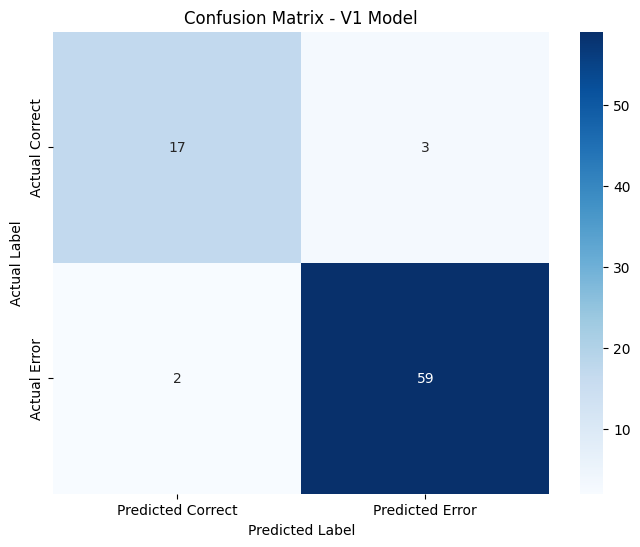

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the model's predictions on the test set
y_pred_probs = loaded_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1) # Convert probabilities [0.1, 0.9] to a class 0 or 1

# --- 1. Classification Report ---
print("\n--- Classification Report ---")
# 'target_names' makes the report readable
print(classification_report(y_test, y_pred_classes, target_names=["Class 0 (Correct)", "Class 1 (Error)"]))


# --- 2. Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix for a clear visual
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted Correct", "Predicted Error"],
            yticklabels=["Actual Correct", "Actual Error"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - V1 Model')
plt.show()